# 06 — Major Backtest: Model Predictions vs Real Results

Parses `resultados_reais.md`, runs `predict_match()` for every match, and
compares the predicted winner against the actual result.

> **Note:** The model was trained on 2012–2020 HLTV data. Teams from recent
> majors may not exist in the lookup — those matches will use zeroed/imputed
> features and the prediction should be interpreted with caution.

Run `03_training.ipynb` first to generate the saved model.

In [2]:
import re
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

from conf.settings import PROCESSED_DIR, DATASET_FILE, RAW_DIR
from src.module.model.model import CSWinnerModel
from src.module.model.features import build_features, build_team_stats_lookup

%matplotlib inline

## 1. Parse Match Results from Markdown

In [3]:
XLSX_FILE = RAW_DIR / "lasta_major_dataset" / "resultados_reais.xlsx"


def _parse_score(score: str):
    """Return (left, right) int tuple, or None if score contains '?'."""
    score = str(score).strip()
    if '?' in score:
        return None
    m = re.match(r'^(\d+)-(\d+)$', score)
    return (int(m.group(1)), int(m.group(2))) if m else None


def _winner_from_score(score: str):
    parsed = _parse_score(score)
    if parsed is None:
        return None
    l, r = parsed
    if l > r: return 'team1'
    if r > l: return 'team2'
    return None


def _fmt_from_score(score: str, section: str = '') -> str:
    """Infer bo1 vs bo3 from score magnitude or section name."""
    if 'BO3' in section.upper():
        return 'bo3'
    parsed = _parse_score(score)
    if parsed and max(parsed) <= 2:
        return 'bo3'
    return 'bo1'


def parse_xlsx_matches(path: Path) -> pd.DataFrame:
    """Read all sheets from the xlsx and build a unified match DataFrame."""
    sheets = pd.read_excel(path, sheet_name=None)
    matches = []
    for section, df in sheets.items():
        df.columns = [c.strip() for c in df.columns]
        for _, row in df.iterrows():
            team1 = str(row.get('Team 1', '')).strip()
            team2 = str(row.get('Team 2', '')).strip()
            score = str(row.get('Score', '')).strip()
            rnd = row.get('Round', None)
            bracket = row.get('Bracket', None)

            if not team1 or not team2 or not score or team1 == 'nan' or team2 == 'nan':
                continue

            winner = _winner_from_score(score)
            if winner is None:
                continue

            fmt = _fmt_from_score(score, section)
            matches.append({
                'section': section,
                'round': rnd,
                'bracket': bracket,
                'team1': team1,
                'team2': team2,
                'score': score,
                'format': fmt,
                'actual_winner': winner,
                'actual_winner_name': team1 if winner == 'team1' else team2,
            })
    return pd.DataFrame(matches)


matches_df = parse_xlsx_matches(XLSX_FILE)
print(f'Parsed {len(matches_df)} complete matches (skipped ones with "?").')
matches_df.head(10)

Parsed 71 complete matches (skipped ones with "?").


,section,round,bracket,team1,team2,score,format,actual_winner,actual_winner_name
0,Detailed Results - STAGE 1,1,0-0,B8,TYLOO,13-6,bo1,team1,B8
1,Detailed Results - STAGE 1,1,0-0,M80,Lynn Vision,13-8,bo1,team1,M80
2,Detailed Results - STAGE 1,1,0-0,Liquid,BIG,13-10,bo1,team1,Liquid
3,Detailed Results - STAGE 1,1,0-0,BetBoom,Gaimin Gladiators,13-4,bo1,team1,BetBoom
4,Detailed Results - STAGE 1,1,0-0,GamerLegion,FlyQuest,13-11,bo1,team1,GamerLegion
5,Detailed Results - STAGE 1,2,1-0,M80,Sharks,13-6,bo1,team1,M80
6,Detailed Results - STAGE 1,2,1-0,B8,THUNDER dOWNUNDER,13-11,bo1,team1,B8
7,Detailed Results - STAGE 1,2,1-0,GamerLegion,FlyQuest,13-11,bo1,team1,GamerLegion
8,Detailed Results - STAGE 1,2,1-0,BetBoom,Liquid,13-9,bo1,team1,BetBoom
9,Detailed Results - STAGE 1,2,0-1,Lynn Vision,HEROIC,13-11,bo1,team1,Lynn Vision


## 2. Load Model and Team Stats Lookup

In [4]:
model = CSWinnerModel.load()
print('Model loaded.')

df_all = pd.read_parquet(PROCESSED_DIR / DATASET_FILE)
df_all = build_features(df_all)
lookup = build_team_stats_lookup(df_all)

print(f'Teams in lookup: {len(lookup)}')

2026-06-19 10:40:31 | INFO     | utils.file_utils:101 | Loading pickle: E:\projects\folder-counter-strike-winner\counter-strike-winner\models\xgboost_pipeline.pkl
Model loaded.
2026-06-19 10:40:31 | INFO     | src.module.model.features:153 | === Feature Engineering — 13 modules | 105284 rows ===
2026-06-19 10:40:31 | INFO     | src.module.model.features:156 |   [ 1/13] map_features               [helper] map_win_rate, maps_advantage
2026-06-19 10:40:31 | INFO     | src.module.model.features:160 |          done in 0.0s  →  52 cols total
2026-06-19 10:40:31 | INFO     | src.module.model.features:156 |   [ 2/13] player_features            [helper] kill_death_ratio_team1/2
2026-06-19 10:40:32 | INFO     | src.module.model.features:160 |          done in 0.0s  →  54 cols total
2026-06-19 10:40:32 | INFO     | src.module.model.features:156 |   [ 3/13] differential_features      [helper] rating_diff, adr_diff, kast_diff
2026-06-19 10:40:32 | INFO     | src.module.model.features:160 |         

## 3. Check Team Coverage

Teams not found in the lookup have no historical data — the model will use
imputed (mean) feature values for them, making predictions less reliable.

In [5]:
all_teams = set(matches_df['team1'].unique()) | set(matches_df['team2'].unique())
in_lookup = {t for t in all_teams if t in lookup}
missing = all_teams - in_lookup

print(f'Teams in matches : {len(all_teams)}')
print(f'Found in lookup  : {len(in_lookup)}')
print(f'Missing (no data): {len(missing)}')
if missing:
    print('\nMissing teams (predictions use imputed features):')
    for t in sorted(missing):
        print(f'  - {t}')

Teams in matches : 35
Found in lookup  : 33
Missing (no data): 2

Missing teams (predictions use imputed features):
  - NAVI
  - PV


## 4. Run Predictions for All Matches

In [6]:
import logging
logging.disable(logging.WARNING)  # silence per-match model logs

results = []
for _, row in matches_df.iterrows():
    try:
        pred = model.predict_match(
            team1=row['team1'],
            team2=row['team2'],
            match_format=row['format'],
            stage=row['section'],
            team_stats=lookup,
        )
        predicted_side = 'team1' if pred['predicted_winner'] == row['team1'] else 'team2'
        results.append({
            **row.to_dict(),
            'predicted_winner': pred['predicted_winner'],
            'predicted_side': predicted_side,
            'prob_team1': pred['prob_team1_wins'],
            'prob_team2': pred['prob_team2_wins'],
            'elo_diff': pred['elo_diff'],
            'correct': predicted_side == row['actual_winner'],
            't1_in_lookup': row['team1'] in lookup,
            't2_in_lookup': row['team2'] in lookup,
        })
    except Exception as e:
        results.append({
            **row.to_dict(),
            'predicted_winner': 'ERROR',
            'predicted_side': None,
            'prob_team1': float('nan'),
            'prob_team2': float('nan'),
            'elo_diff': float('nan'),
            'correct': None,
            't1_in_lookup': row['team1'] in lookup,
            't2_in_lookup': row['team2'] in lookup,
        })

logging.disable(logging.NOTSET)

res = pd.DataFrame(results)
print(f'Predictions complete: {len(res)} matches.')

Predictions complete: 71 matches.


## 5. Full Results Table

In [7]:
display_cols = ['section', 'round', 'bracket', 'team1', 'team2', 'score', 'format',
                'actual_winner_name', 'predicted_winner', 'correct',
                'prob_team1', 'prob_team2', 'elo_diff']

def _style_row(row):
    base = [''] * len(row)
    correct_idx = list(row.index).index('correct')
    if row['correct'] is True:
        base[correct_idx] = 'background-color: #d4edda; color: #155724'
    elif row['correct'] is False:
        base[correct_idx] = 'background-color: #f8d7da; color: #721c24'
    return base

(
    res[display_cols]
    .style
    .apply(_style_row, axis=1)
    .format({
        'prob_team1': '{:.1%}',
        'prob_team2': '{:.1%}',
        'elo_diff': '{:+.1f}',
    }, na_rep='-')
)

,section,round,bracket,team1,team2,score,format,actual_winner_name,predicted_winner,correct,prob_team1,prob_team2,elo_diff
0,Detailed Results - STAGE 1,1,0-0,B8,TYLOO,13-6,bo1,B8,B8,True,50.7%,49.3%,+37.4
1,Detailed Results - STAGE 1,1,0-0,M80,Lynn Vision,13-8,bo1,M80,Lynn Vision,False,47.2%,52.8%,+11.9
2,Detailed Results - STAGE 1,1,0-0,Liquid,BIG,13-10,bo1,Liquid,BIG,False,32.0%,68.0%,-88.2
3,Detailed Results - STAGE 1,1,0-0,BetBoom,Gaimin Gladiators,13-4,bo1,BetBoom,BetBoom,True,79.1%,20.9%,+310.0
4,Detailed Results - STAGE 1,1,0-0,GamerLegion,FlyQuest,13-11,bo1,GamerLegion,GamerLegion,True,61.9%,38.1%,+156.2
5,Detailed Results - STAGE 1,2,1-0,M80,Sharks,13-6,bo1,M80,M80,True,57.9%,42.1%,+80.0
6,Detailed Results - STAGE 1,2,1-0,B8,THUNDER dOWNUNDER,13-11,bo1,B8,B8,True,61.5%,38.5%,+140.9
7,Detailed Results - STAGE 1,2,1-0,GamerLegion,FlyQuest,13-11,bo1,GamerLegion,GamerLegion,True,61.9%,38.1%,+156.2
8,Detailed Results - STAGE 1,2,1-0,BetBoom,Liquid,13-9,bo1,BetBoom,BetBoom,True,73.5%,26.5%,+234.6
9,Detailed Results - STAGE 1,2,0-1,Lynn Vision,HEROIC,13-11,bo1,Lynn Vision,Lynn Vision,True,64.0%,36.0%,+67.7


## 6. Overall Accuracy

In [8]:
valid = res.dropna(subset=['correct'])
n_correct = valid['correct'].sum()
n_total = len(valid)
accuracy = n_correct / n_total if n_total > 0 else float('nan')

# Split by lookup coverage
both_known  = valid[valid['t1_in_lookup'] & valid['t2_in_lookup']]
any_unknown = valid[~(valid['t1_in_lookup'] & valid['t2_in_lookup'])]

print('=' * 45)
print(f'  Total matches evaluated : {n_total}')
print(f'  Correct predictions     : {int(n_correct)}')
print(f'  Overall accuracy        : {accuracy:.1%}')
print('=' * 45)
if len(both_known) > 0:
    acc_known = both_known['correct'].mean()
    print(f'  Both teams in lookup    : {len(both_known)} matches  →  {acc_known:.1%} accuracy')
if len(any_unknown) > 0:
    acc_unk = any_unknown['correct'].mean()
    print(f'  At least 1 team missing : {len(any_unknown)} matches  →  {acc_unk:.1%} accuracy')
print('=' * 45)

  Total matches evaluated : 71
  Correct predictions     : 49
  Overall accuracy        : 69.0%
  Both teams in lookup    : 65 matches  →  69.2% accuracy
  At least 1 team missing : 6 matches  →  66.7% accuracy


## 7. Accuracy by Stage / Section

In [9]:
by_section = (
    valid
    .groupby('section')['correct']
    .agg(matches='count', correct='sum')
    .assign(accuracy=lambda d: d['correct'] / d['matches'])
    .sort_values('accuracy', ascending=False)
)
by_section.style.format({'accuracy': '{:.1%}'})

,matches,correct,accuracy
section,,,
Round 1 (BO3),8,8,100.0%
Round 3 High (2-0),2,2,100.0%
Round 3 Low (0-2),2,2,100.0%
Round 4 High (2-1) - BO3,3,3,100.0%
Round 5 (2-2) - BO3,3,3,100.0%
Detailed Results - STAGE 1,17,13,76.5%
Round 4 High (2-1),3,2,66.7%
Round 4 Low (1-2) - BO3,3,2,66.7%
Round 5 (2-2),3,2,66.7%


## 8. Confidence Analysis

How confident was the model when it was right vs wrong?

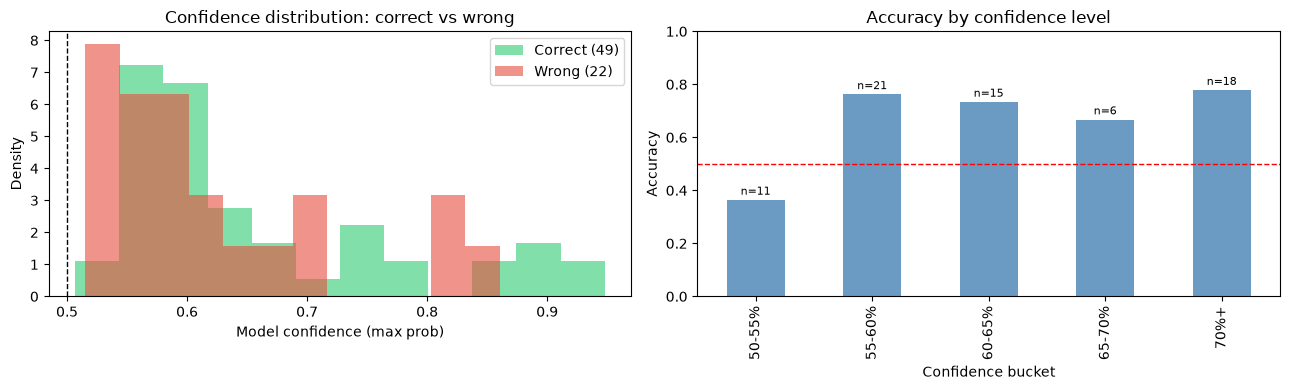

In [10]:
# Confidence = max(prob_team1, prob_team2)
valid = res.dropna(subset=['correct', 'prob_team1', 'prob_team2']).copy()
valid['confidence'] = valid[['prob_team1', 'prob_team2']].max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: confidence distribution — correct vs wrong
ax = axes[0]
for label, color, name in [(True, '#2ecc71', 'Correct'), (False, '#e74c3c', 'Wrong')]:
    subset = valid[valid['correct'] == label]['confidence']
    ax.hist(subset, bins=12, alpha=0.6, color=color, label=f'{name} ({len(subset)})', density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Model confidence (max prob)')
ax.set_ylabel('Density')
ax.set_title('Confidence distribution: correct vs wrong')
ax.legend()

# Right: accuracy by confidence bucket
ax = axes[1]
buckets = pd.cut(valid['confidence'], bins=[0.4, 0.5, 0.55, 0.6, 0.65, 0.7, 1.0],
                 labels=['40-50%', '50-55%', '55-60%', '60-65%', '65-70%', '70%+'])
bucket_acc = valid.groupby(buckets)['correct'].agg(['mean', 'count'])
bucket_acc['mean'].plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_xlabel('Confidence bucket')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by confidence level')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1)
ax.set_ylim(0, 1)
for p, (_, row_b) in zip(ax.patches, bucket_acc.iterrows()):
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.02,
            f'n={int(row_b["count"])}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 9. Biggest Upsets

Matches where the model was most confident but got it wrong.

In [11]:
wrong = valid[valid['correct'] == False].copy()
wrong = wrong.sort_values('confidence', ascending=False)

print('Top 10 biggest upsets (model most confident, but wrong):')
(
    wrong[['section', 'team1', 'team2', 'score', 'actual_winner_name',
           'predicted_winner', 'prob_team1', 'prob_team2', 'confidence']]
    .head(10)
    .style
    .format({'prob_team1': '{:.1%}', 'prob_team2': '{:.1%}', 'confidence': '{:.1%}'})
    .background_gradient(subset=['confidence'], cmap='Reds')
)

Top 10 biggest upsets (model most confident, but wrong):


,section,team1,team2,score,actual_winner_name,predicted_winner,prob_team1,prob_team2,confidence
32,Round 2 Low (0-1),NAVI,Legacy,2-0,NAVI,Legacy,13.9%,86.1%,86.1%
66,Round 4 Low (1-2),MongolZ,Monte,2-1,MongolZ,Monte,17.1%,82.9%,82.9%
69,Round 5 (2-2),BB,FUT,2-0,BB,FUT,17.5%,82.5%,82.5%
25,Round 2 High (1-0),FURIA,MOUZ,2-1,FURIA,MOUZ,28.7%,71.3%,71.3%
27,Round 2 High (1-0),Vitality,9z,1-2,9z,Vitality,69.3%,30.7%,69.3%
2,Detailed Results - STAGE 1,Liquid,BIG,13-10,Liquid,BIG,32.0%,68.0%,68.0%
65,Round 4 Low (1-2),MOUZ,FUT,1-2,FUT,MOUZ,63.2%,36.8%,63.2%
38,Round 3 Mid (1-1),Vitality,MOUZ,2-1,Vitality,MOUZ,37.4%,62.6%,62.6%
14,Detailed Results - STAGE 1,B8,M80,2-0,B8,M80,39.8%,60.2%,60.2%
24,Round 1 - STAGE 2,Legacy,MIBR,8-13,MIBR,Legacy,60.1%,39.9%,60.1%


## 10. Most Confident Correct Predictions

In [12]:
correct = valid[valid['correct'] == True].copy()
correct = correct.sort_values('confidence', ascending=False)

print('Top 10 most confident correct predictions:')
(
    correct[['section', 'team1', 'team2', 'score', 'actual_winner_name',
             'predicted_winner', 'prob_team1', 'prob_team2', 'confidence']]
    .head(10)
    .style
    .format({'prob_team1': '{:.1%}', 'prob_team2': '{:.1%}', 'confidence': '{:.1%}'})
    .background_gradient(subset=['confidence'], cmap='Greens')
)

Top 10 most confident correct predictions:


,section,team1,team2,score,actual_winner_name,predicted_winner,prob_team1,prob_team2,confidence
64,Round 4 High (2-1),NAVI,Falcons,1-2,Falcons,Falcons,5.2%,94.8%,94.8%
56,Round 1 (BO3),NAVI,Spirit,0-2,Spirit,Spirit,6.9%,93.1%,93.1%
62,Round 4 High (2-1),BB,Vitality,0-2,Vitality,Vitality,9.3%,90.7%,90.7%
68,Round 5 (2-2),9z,MongolZ,2-0,9z,9z,90.0%,10.0%,90.0%
70,Round 5 (2-2),NAVI,G2,1-2,G2,G2,12.3%,87.7%,87.7%
59,Round 3 High (2-0),BB,FURIA,0-2,FURIA,FURIA,13.7%,86.3%,86.3%
61,Round 3 Low (0-2),PV,Legacy,0-2,Legacy,Legacy,13.9%,86.1%,86.1%
3,Detailed Results - STAGE 1,BetBoom,Gaimin Gladiators,13-4,BetBoom,BetBoom,79.1%,20.9%,79.1%
28,Round 2 High (1-0),Aurora,Spirit,1-2,Spirit,Spirit,23.3%,76.7%,76.7%
33,Round 3 High (2-0) - BO3,Spirit,9z,2-0,Spirit,Spirit,75.8%,24.2%,75.8%


## 11. Per-Team Prediction Record

In [ ]:
# Build record: how often was each team's result correctly predicted?
team_rows = []
for _, row in valid.iterrows():
    for side, team in [('team1', row['team1']), ('team2', row['team2'])]:
        in_lkp = row[f't{side[-1]}_in_lookup'] if side == 'team1' else row['t2_in_lookup']
        team_rows.append({
            'team': team,
            'correct': row['correct'],
            'in_lookup': in_lkp,
        })

team_df = (
    pd.DataFrame(team_rows)
    .groupby(['team', 'in_lookup'])['correct']
    .agg(matches='count', correct='sum')
    .assign(accuracy=lambda d: d['correct'] / d['matches'])
    .sort_values('matches', ascending=False)
    .reset_index()
)

team_df.style.format({'accuracy': '{:.1%}'}).background_gradient(
    subset=['accuracy'], cmap='RdYlGn', vmin=0, vmax=1
)

,team,in_lookup,matches,correct,accuracy
0,B8,True,10,7,70.0%
1,G2,True,8,6,75.0%
2,9z,True,8,6,75.0%
3,Legacy,True,7,5,71.4%
4,Monte,True,7,5,71.4%
5,FUT,True,7,3,42.9%
6,BetBoom,True,7,6,85.7%
7,TYLOO,True,6,5,83.3%
8,Spirit,True,5,5,100.0%
9,NAVI,False,5,3,60.0%


: 

## 12. Quando o modelo estava mais confiante, ele acertou mais?

**Gráfico esquerdo — Curva cumulativa de acurácia:**  
Ordena todas as partidas da mais para a menos confiante. Começa com as N mais confiantes e vai adicionando as menos confiantes. Se a linha cai da esquerda para a direita, o modelo acerta mais quando está confiante.

**Gráfico direito — Curva de calibração (reliability diagram):**  
Para cada nível de confiança previsto (eixo X), qual foi a proporção real de acertos (eixo Y)? Um modelo perfeitamente calibrado ficaria na diagonal. Acima da diagonal = subestima a própria chance de errar. Abaixo = superestima.

In [ ]:
scored = valid.copy()
scored['confidence'] = scored[['prob_team1', 'prob_team2']].max(axis=1)
scored = scored.sort_values('confidence', ascending=False).reset_index(drop=True)

# --- cumulative accuracy ---
cum_acc = scored['correct'].expanding().mean().values
x_cum = np.arange(1, len(scored) + 1)

# --- calibration curve ---
n_bins = 8
scored['conf_bin'] = pd.cut(scored['confidence'], bins=n_bins)
calib = scored.groupby('conf_bin', observed=True)['correct'].agg(['mean', 'count']).reset_index()
bin_centers = calib['conf_bin'].apply(lambda b: b.mid).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: cumulative accuracy curve ---
ax = axes[0]
ax.plot(x_cum, cum_acc, color='steelblue', linewidth=2, label='Acurácia cumulativa')
ax.axhline(scored['correct'].mean(), color='gray', linestyle='--', linewidth=1,
           label=f'Acurácia geral ({scored["correct"].mean():.1%})')
ax.axhline(0.5, color='red', linestyle=':', linewidth=1, label='Chance (50%)')
ax.fill_between(x_cum, cum_acc, scored['correct'].mean(),
                where=(cum_acc >= scored['correct'].mean()),
                alpha=0.12, color='green', label='Acima da média')
ax.fill_between(x_cum, cum_acc, scored['correct'].mean(),
                where=(cum_acc < scored['correct'].mean()),
                alpha=0.12, color='red', label='Abaixo da média')
ax.set_xlabel('Partidas (ordenadas da maior para a menor confiança)')
ax.set_ylabel('Acurácia cumulativa')
ax.set_title('Mais confiante → mais certo?', fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(1, len(scored))
ax.set_ylim(0.3, 1.0)

# annotate the split between "high confidence zone" and the rest
if len(scored) >= 10:
    top10_acc = scored.head(10)['correct'].mean()
    ax.annotate(
        f'Top 10 mais confiantes\nAcurácia: {top10_acc:.0%}',
        xy=(10, scored.head(10)['correct'].mean()),
        xytext=(18, top10_acc + 0.08),
        fontsize=8,
        arrowprops=dict(arrowstyle='->', color='black'),
    )

# --- right: calibration / reliability diagram ---
ax = axes[1]
ax.plot([0.5, 1.0], [0.5, 1.0], 'k--', linewidth=1, label='Calibração perfeita')
sc = ax.scatter(
    bin_centers,
    calib['mean'],
    s=calib['count'] * 18,
    c=calib['mean'],
    cmap='RdYlGn',
    vmin=0.3,
    vmax=1.0,
    edgecolors='gray',
    linewidths=0.5,
    zorder=3,
)
ax.plot(bin_centers, calib['mean'], color='steelblue', linewidth=1.5, alpha=0.7)
for _, row_c in calib.iterrows():
    if pd.notna(row_c['mean']):
        ax.text(
            row_c['conf_bin'].mid, row_c['mean'] + 0.025,
            f"n={int(row_c['count'])}",
            ha='center', fontsize=7.5, color='#333333',
        )
plt.colorbar(sc, ax=ax, label='Acurácia real')
ax.set_xlabel('Confiança prevista pelo modelo')
ax.set_ylabel('Acurácia real no bin')
ax.set_title('Curva de calibração', fontweight='bold')
ax.set_xlim(0.48, 1.02)
ax.set_ylim(0.2, 1.1)
ax.legend(fontsize=8)

fig.suptitle('Confiança do modelo vs Acertos reais', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nConfiança média nas partidas CERTAS : {scored[scored["correct"]==True]["confidence"].mean():.1%}')
print(f'Confiança média nas partidas ERRADAS: {scored[scored["correct"]==False]["confidence"].mean():.1%}')